## Author: Abdelaziz Neamatallah
### Date: 24.10.25
### Desc: This task should show the similarity between different datasets.

- The goal of this task is to analyze the similarity of the provided network traffic between the different files, in which it was collected. 
- So, we need to write a piece of code that satisfies the following requirements

1. For each of our datasets, we need to generate **traffic flows** from the corresponding network traffic.
    - Each flow should correspond to a time window of {2,4,6} mins and should only contain traffic exchanged between two communicating parties over the same highest-lecel protocol.
   - From the corresponding sequence of packets belonging to a given flow, we should extract only:
     - packet size
     - direction
     - inter-arrival packet time
   - All flows should have the same length.
   - And we should ensure that we do not lose information for longer flows.
   - Finally, we should differentiate between flows containing packets under attack, and those without attacks.

- Now lets try to understand some basic concepts before we proceed.
- Traffic flow mean: 
  - Think of the PCAP dataset as a long list of packets captured over time, which includes thousands of messages exchanged between many devices. 
  - A flow is a group of packets, that all belong to the same communication session between two hosts using the same protocol within a given time window.
  - in other words: all packets sent between host A and host B over the same protocol during X minutes. 
  - usually the traffic will looks like:

| Time (s) | Source       | Destination  | Protocol | Length | Attack? |
| -------- | ------------ | ------------ | -------- | ------ | ------- |
| 0.1      | 192.168.1.10 | 192.168.1.20 | S7comm   | 120    | No      |
| 0.2      | 192.168.1.20 | 192.168.1.10 | S7comm   | 130    | No      |
| 10.5     | 192.168.1.11 | 192.168.1.30 | HTTP     | 900    | Yes     |

  - So, you can see the first two packets are between the same pair using the same protocol, so they belong to one flow, and the last one is different so it belongs to another flow.
- Now, after we understood what does traffic flow means, we need o generate traffic flows for three durations:
  - 2 minutes
  - 4 minutes
  - 6 minutes
- this mean that we need to slice the whole capture timeline into chunks of 2,4, and 6 minutes each
  - 0:0 - 0:2 => flow window 1
  - 0:2 - 0:4 => flow window 2
- inside each window, we should group the packets by:
  - same source IP, destination IP, and protocol
  - each group will represent one flow.
- Then we should extract features from packets inside each flow
  - Packet size
  - Directions
  - Inter-arrival time (IAT): this is the time difference between consecutive packets in that flow, so each flow should look like a triplets.  
- It was mentioned that we need to diffrentiate between the packets marked as attacked, and other marked as normal.
- Also, all flows should have the same length. 

### Understanding of the datasets:
#### 2017QUT_S7Comm
- It consists of 3 sub-directories
  1. Graphs: 
  
| File / Folder              | Description                                                                                                                                                        |
| -------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **`tshark_attacks`**       | Output of `tshark` (Wireshark CLI) during attack captures — lists packets, timestamps, fields (like function codes, packet sizes, etc.) for sessions under attack. |
| **`tshark_control`**       | Same, but for *normal (control)* traffic — used as baseline.                                                                                                       |
| **`gnuplot_graphs.gplot`** | A **Gnuplot** script that plots network statistics (e.g., number of S7 packets per second). Used to reproduce figures in their publication.                        |
| **`SCADA_traffic.ps`**     | PostScript plot (graph) showing SCADA traffic volume or timing patterns — likely an exported visualization.                                                        |

  2. LabeledDataset: => this is the core folder for us
     - It consists of 2 labeled datasets:
       - control_set: describes the regular operating procedure without incidents
       - s7_process_attacks: describes an operational sequence that is manipulated by an attacker 
  3. Logs:
     - Stores experiment log files from each participant system
- So, we can conclude that we will interact only with the LabeledDataset folder  

### Understanding the structure of s7_process_attacks:
- They captured network traffic from several network interfaces
  - Master: PLC or central controller
  - HMI: From the Human machine interface
  - Attacker: attacker traffic
- This contains one complete attack experiment, and these are the key files
    - master.pcap => these are the packets captured on the PLC or controller side, shows legitimate and injected commands received => this is the main dataset to analyze in our task
    - hmi.pcap => packets captured on the HMI (SCADA interface) side => also useful to be analyzed
    - attacker.pcap => Traffic seen by the attacking host, includes crafted malicious S7comm packets
- Then there is a folder called 20161215202830 => this looks like a date and time (2016/12/15 at 20:28:30 o'clock)
  - it contains subfolders each with a date then . the source of these data, and each folder contains some pcap files, following the same structure also
    - master
    - hmi
    - attacker
- I think, but I am not sure, that the attacker.pcap is a collection for all these sub-folders.pcap
- and same for hmi, and master. => Ask Dr. Asya
- List of process attacks:
  - 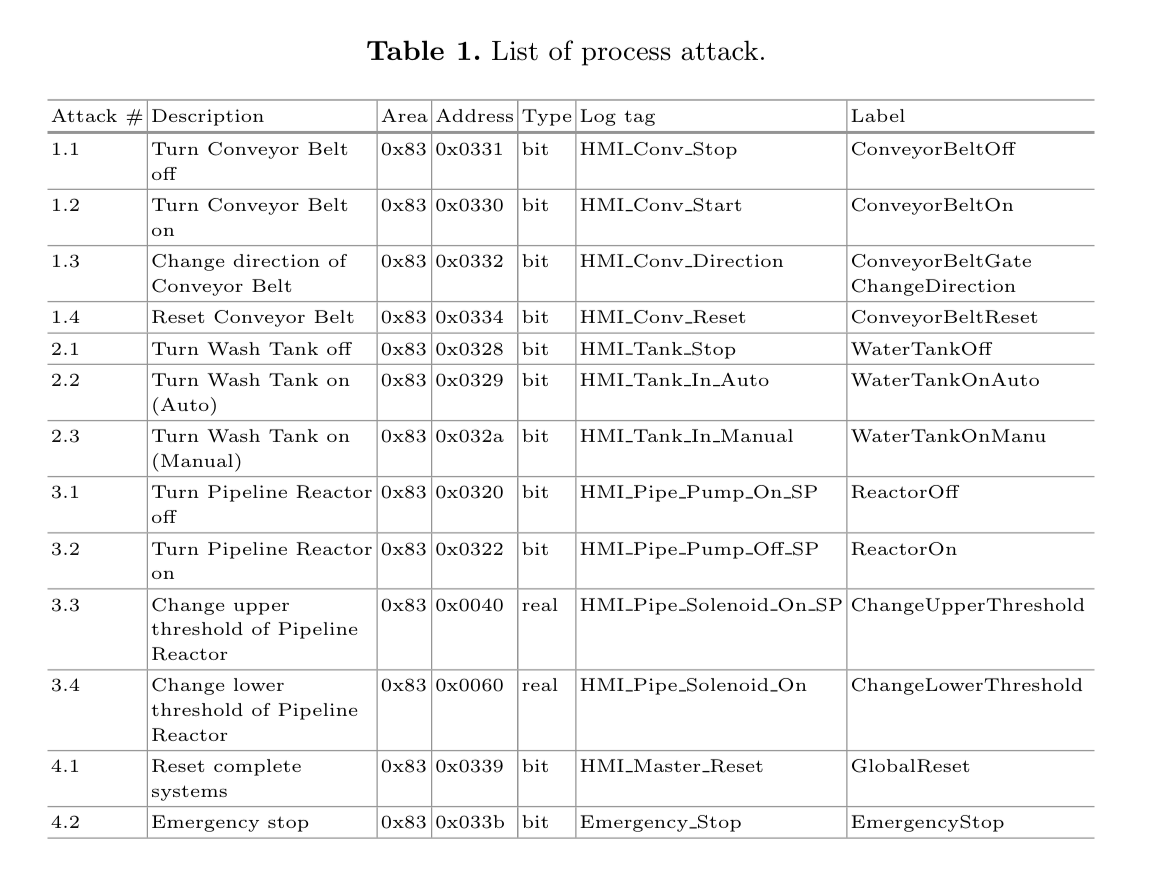
- All process attacks (64)
  - 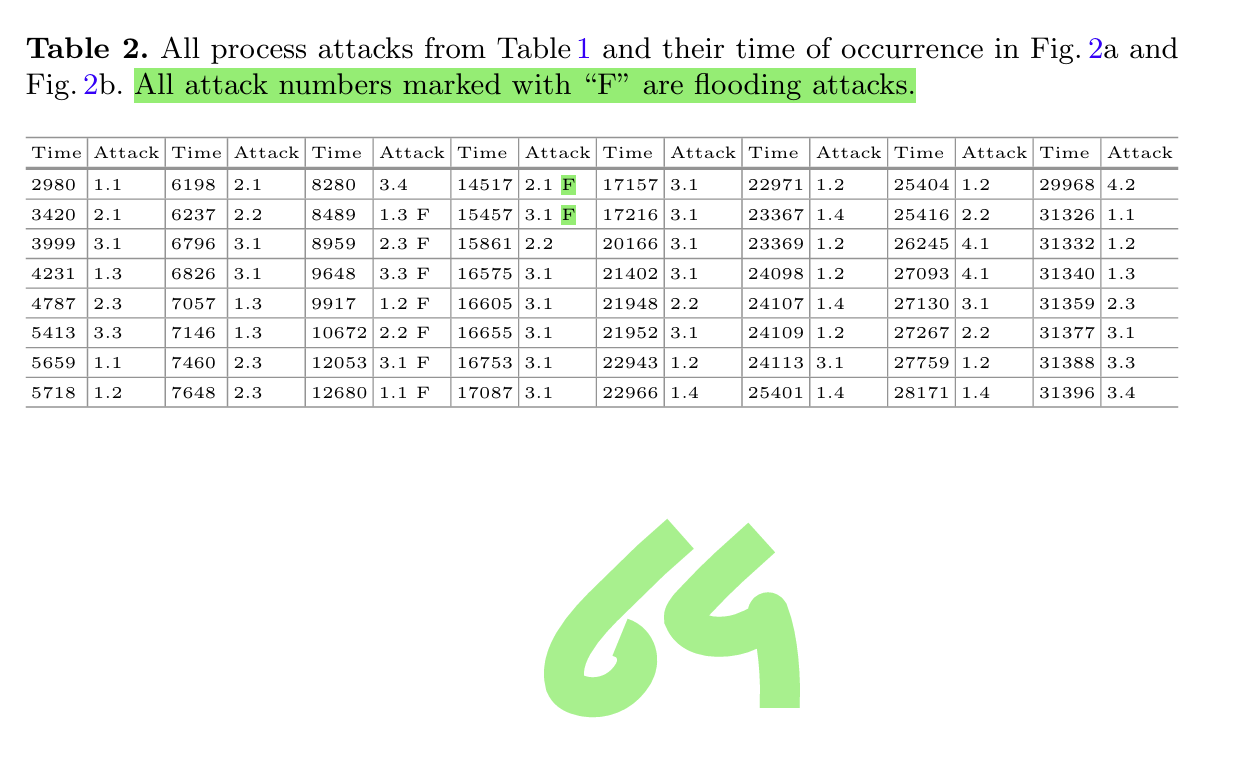

### Understanding of control_set
- This is much easier, it just contains three sub-files
  - Attacker.pcap
  - HMI.pcap
  - master.pcap

### Understanding of electra_S7comm dataset
- this is a .csv file, it is not pcap, should we handle it as is?
- [Dataset explaination](http://perception.inf.um.es/ICS-datasets/)
- There are Three categories and seven classes of attacks in the Electra dataset
  - 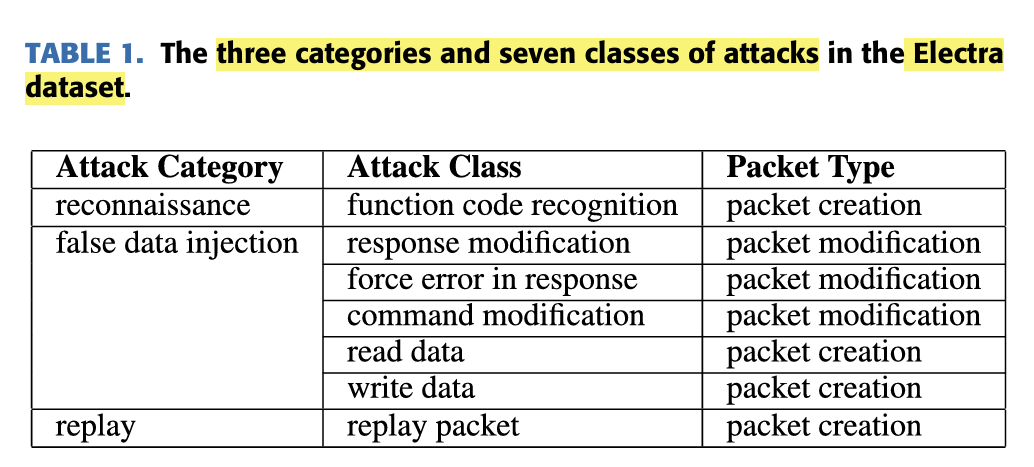
- Reconnaissance attacks: They are aimed at identifying  potential victims within a network. After gaining access to an industrial network, an attacker needs to perform a reconnaissance attack to get information about the different devices that are in the network and their associated services. From this information, the attacker usually plans the next move.
-  False data injection attacks: They are aimed at controlling the control devices of an ICS. To achieve this goal, these attacks are based on sending altered data through control protocols. False data injection attacks can be classi ed depending on the data they alter into: Command Injection, Response Injection and Parameter Injection, just to name a few.
- Replay attacks: They are based on retransmitting valid packets that have been previously seen in the network. This action can alter the normal reception rate of that packet in a device or can mislead a device by sending an unexpected but apparently valid packet to it. In ICS, these attacks can have as much impact as the false data injection attacks, but they are harder to detect because the packet payload is valid.

### How Electra Dataset has been generated
- It is an electric traction substation employed in a real high-speed railway industry, the main goal is to convert the electric power into voltage, current, and frequency to supply railways or trams. This system can be used to convert the three-phase AC current to single-phase with the lower frequency needed for rail-way electrical system. 
- The system consists of the following architecture:
  - 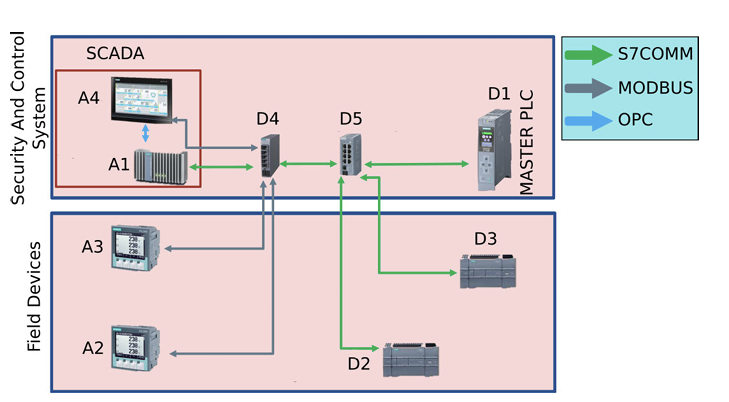
    - it has 5 PLCs ( 1 master, and 4 slaves )
    - switch called D5 for the interconnection of the different devices.
    - firewall called D4 to protect the substation from attacks coming from outside. 
    - The testbed communicate through control protocols following master-slave architecture, where the master initiates the communication requesting some data, and a slave replies with the requested information.
    - They use the following protocols:
      - Modbus TCP
      - S7comm
      - OPC
    - SCADA System consists of
      - HMI (A4)
      - Nanobox (A1)
      - they communicate via OPC protocol
      - The SCADA acts as the master for the two SCADA slaves (A2) and (A3)
    - Similarly for the S7comm:
      - D1 PLC acts as the master for (A1, D2, D3)
- Here are the IP and MAC addresses for the devices on the system:
  - 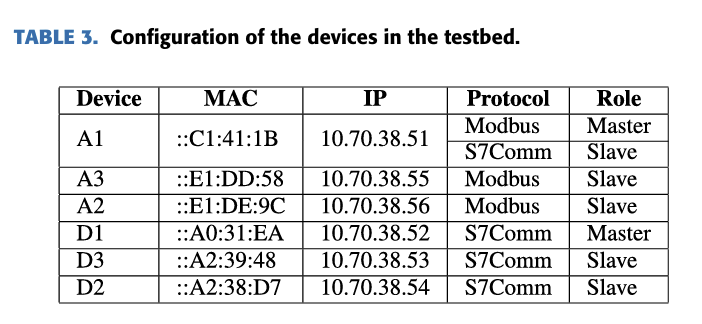
  - 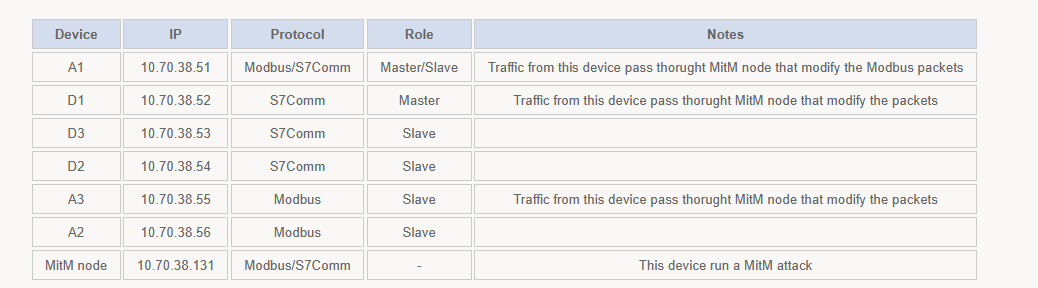
- The attacked nodes for S7comm shuld be D1 and D2
- Traffic on S7comm should be on port 102
- Spectra selected features: 
  - 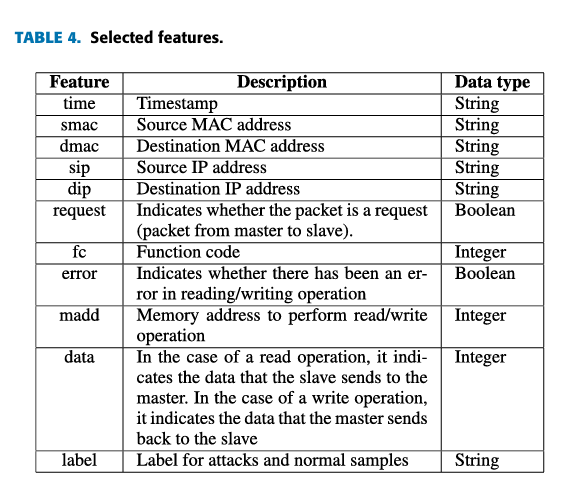

In [ ]:
# reading the dataset in form of chunks
import pandas as pd 
chunks = pd.read_csv('../../DataSets/electra_s7comm/electra_s7comm.csv',chunksize = 500000)

# count number of chunks
# count = 0 

# for chunk in chunks:
#     count += 1

# print(f"Number of chunks: {count}")

- number of chunks is 194
- chunks is of type TextFileReader which is an iterator created by pandas when we use the chunksize
- each chunk is a DataFrame representing 2M points of the Dataset result in having 194 chuncks
- [reference](https://stackoverflow.com/questions/25962114/how-do-i-read-a-large-csv-file-with-pandas) 

In [29]:
print(type(chunks))

first_chunk = next(chunks)

print(type(first_chunk))

<class 'pandas.io.parsers.readers.TextFileReader'>
<class 'pandas.core.frame.DataFrame'>


In [23]:
first_chunk.columns

Index(['Time', 'smac', 'dmac', 'sip', 'dip', 'request', 'fc', 'error',
       'address', 'data', 'label'],
      dtype='object')

In [24]:
first_chunk.Time.unique()

array([        0,       330,       654, ..., 200433566, 200433867,
       200434218], shape=(71693,))

In [25]:
first_chunk["Time"] = first_chunk["Time"] / 1_000_000
first_chunk.Time.unique()

array([0.00000000e+00, 3.30000000e-04, 6.54000000e-04, ...,
       2.00433566e+02, 2.00433867e+02, 2.00434218e+02], shape=(71693,))

In [ ]:
# add another two columns named s_device and d_device, to easily identify the source and destination devices based on their IP addresses
def set_devices(df):
    if df.sip == '10.70.38.51':
        df['s_device'] = 'A1'
    elif df.sip == '10.70.38.52':
        df['s_device'] = 'D1'
    elif df.sip == '10.70.38.53':
        df['s_device'] = 'D3'
    elif df.sip == '10.70.38.54':
        df['s_device'] = 'D2'
    elif df.sip == '10.70.38.55':
        df['s_device'] = 'A3'
    elif df.sip == '10.70.38.56':
        df['s_device'] = 'A2'
    # set destination device
    if df.dip == '10.70.38.51':
        df['d_device'] = 'A1'
    elif df.dip == '10.70.38.52':
        df['d_device'] = 'D1'
    elif df.dip == '10.70.38.53':
        df['d_device'] = 'D3'
    elif df.dip == '10.70.38.54':
        df['d_device'] = 'D2'
    elif df.dip == '10.70.38.55':
        df['d_device'] = 'A3'
    elif df.dip == '10.70.38.56':
        df['d_device'] = 'A2'
    return df

df = first_chunk.apply(set_devices, axis=1)
print(df[:10])

# This set takes too much time to run on one chunk only. => 28:30 mins to run on one chunk
# estimated for 194 chunks = 194 * 28.5 mins = 5529 mins = 92 hours = 3.8 days => crazy time

   Time               smac               dmac          sip          dip  \
0     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
1     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
2     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
3     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
4     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
5     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
6     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
7     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
8     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   
9     0  28:63:36:a2:39:48  28:63:36:a0:31:ea  10.70.38.53  10.70.38.52   

   request  fc  error  address  data   label s_device d_device  
0        1   5      0    10560     1  NORMAL       D3       D1  
1        1   5      0    10562     2  NORMAL

In [69]:
# spliting the dataset into attacked and normal data
normal_data = df[df['label'] == 'NORMAL']
attacked_data = df[df['label'] != 'NORMAL']

print("Normal data shape: ", normal_data.shape)
print("Attacked data shape: ", attacked_data.shape)

Normal data shape:  (1044144, 13)
Attacked data shape:  (955856, 13)


In [70]:
# Print different types of attacks 
print("Different types of attacks: ", attacked_data['label'].value_counts())


Different types of attacks:  label
MITM_UNALTERED                 935925
FALSE_ERROR_RESPONSE_ATTACK     13986
COMMAND_ATTACK                   4840
RESPONSE_ATTACK                  1105
Name: count, dtype: int64


In [71]:

# print unique time 
print("Unique time values: ", df['Time'].value_counts().sort_index())


Unique time values:  Time
0            66
330          51
654          51
762           1
1751          1
             ..
200431874    66
200432931     1
200433566     1
200433867     1
200434218    20
Name: count, Length: 71693, dtype: int64


In [72]:
normal_request_packets = normal_data[normal_data.request == True]
print("Normal request packets shape: ", normal_request_packets.shape)

attacked_request_packets = attacked_data[attacked_data.request == True]
print("Attacked request packets shape: ", attacked_request_packets.shape)

# extract the resonse packets from the normal data
normal_response_packets = normal_data[normal_data.request == False]
print("Normal response packets shape: ", normal_response_packets.shape)
attacked_response_packets = attacked_data[attacked_data.request == False]
print("Attacked response packets shape: ", attacked_response_packets.shape)

Normal request packets shape:  (619321, 13)
Attacked request packets shape:  (652906, 13)
Normal response packets shape:  (424823, 13)
Attacked response packets shape:  (302950, 13)


In [73]:
# print unique function codes 
print("Unique function codes in normal data: ", normal_data.fc.value_counts())
# 4 is read input registers
# what is 5 ? 

Unique function codes in normal data:  fc
5    610853
4    433291
Name: count, dtype: int64


In [74]:
df.shape

(2000000, 13)

In [18]:
# Working on the first chank only for testing purpose
first_chunk.head()

,Time,smac,dmac,sip,dip,request,fc,error,address,data,label
0,0,28:63:36:a2:39:48,28:63:36:a0:31:ea,10.70.38.53,10.70.38.52,1,5,0,10560,1,NORMAL
1,0,28:63:36:a2:39:48,28:63:36:a0:31:ea,10.70.38.53,10.70.38.52,1,5,0,10562,2,NORMAL
2,0,28:63:36:a2:39:48,28:63:36:a0:31:ea,10.70.38.53,10.70.38.52,1,5,0,10564,1,NORMAL
3,0,28:63:36:a2:39:48,28:63:36:a0:31:ea,10.70.38.53,10.70.38.52,1,5,0,10566,2,NORMAL
4,0,28:63:36:a2:39:48,28:63:36:a0:31:ea,10.70.38.53,10.70.38.52,1,5,0,10568,1,NORMAL


In [ ]:
import ipaddress
# --- 1. Compute packet size ---
# Define the columns that contribute to packet size
def compute_packet_size(row):
    '''
        - we have 3 integers each of 4 bytes: fc, data, address
        - we have 2 booleans 1 byte for each: error, request
        - we have len(label) bytes for the label string + 1 byte for the terminating null character
    '''
    size = 4 * 3 + 1 * 2 + len(row['label']) + 1 # the last 1 is for the terminating null character
    return size
    

first_chunk["packet_size"] = first_chunk.apply(compute_packet_size, axis=1)
# --- 2. Create pair_ip column ---
def create_pair_ip(row):
    try:
        ip1 = ipaddress.ip_address(row["sip"])
        ip2 = ipaddress.ip_address(row["dip"])
        # sort to ensure smallerIP_largerIP order
        return f"{min(ip1, ip2)}_{max(ip1, ip2)}"
    except:
        return None

first_chunk["pair_ip"] = first_chunk.apply(create_pair_ip, axis=1)

# --- 3. Keep only required columns ---
first_chunk_final = first_chunk[["Time","sip",'dip' ,"packet_size", "pair_ip", "request", "label"]]


# --- 4. Optional: sort by time for flow generation ---
first_chunk_final = first_chunk_final.sort_values(by="Time").reset_index(drop=True)

print(first_chunk_final.head())

   Time          sip          dip  packet_size                  pair_ip  \
0     0  10.70.38.53  10.70.38.52           11  10.70.38.52_10.70.38.53   
1     0  10.70.38.53  10.70.38.52           11  10.70.38.52_10.70.38.53   
2     0  10.70.38.53  10.70.38.52           11  10.70.38.52_10.70.38.53   
3     0  10.70.38.53  10.70.38.52           11  10.70.38.52_10.70.38.53   
4     0  10.70.38.53  10.70.38.52           11  10.70.38.52_10.70.38.53   

   request   label  
0        1  NORMAL  
1        1  NORMAL  
2        1  NORMAL  
3        1  NORMAL  
4        1  NORMAL  


In [9]:
# spliting the dataset into attacked and normal data
normal_data = first_chunk[first_chunk['label'] == 'NORMAL']
attacked_data = first_chunk[first_chunk['label'] != 'NORMAL']

print("Normal data shape: ", normal_data.shape)
print("Attacked data shape: ", attacked_data.shape)
print(attacked_data.label.value_counts())

Normal data shape:  (1044144, 13)
Attacked data shape:  (955856, 13)
label
MITM_UNALTERED                 935925
FALSE_ERROR_RESPONSE_ATTACK     13986
COMMAND_ATTACK                   4840
RESPONSE_ATTACK                  1105
Name: count, dtype: int64


In [20]:
first_chunk.Time.unique()

array([  0.      , 330.      , 654.      , ..., 200.433566, 200.433867,
       200.434218], shape=(71693,))

In [ ]:
# iterate over all chunks, separate normal and attacked data, and save them in separate files in csv in this path '../../DataSets/electra_s7comm/output'
index = 0
import ipaddress
# --- 1. Compute packet size ---
# Define the columns that contribute to packet size
def compute_packet_size(row):
    '''
        - we have 3 integers each of 4 bytes: fc, data, address
        - we have 2 booleans 1 byte for each: error, request
        - we have len(label) bytes for the label string + 1 byte for the terminating null character
    '''
    size = 4 * 3 + 1 * 2 + len(row['label']) + 1 # the last 1 is for the terminating null character
    return size
    

# --- 2. Create pair_ip column ---
def create_pair_ip(row):
    try:
        ip1 = ipaddress.ip_address(row["sip"])
        ip2 = ipaddress.ip_address(row["dip"])
        # sort to ensure smallerIP_largerIP order
        return f"{min(ip1, ip2)}_{max(ip1, ip2)}"
    except:
        return None
    

def process_chunk(chunk):

    chunk.Time = chunk.Time / 1_000_000
    chunk["packet_size"] = chunk.apply(compute_packet_size, axis=1)
    chunk["pair_ip"] = chunk.apply(create_pair_ip, axis=1)

    # --- 3. Keep only required columns ---
    chunk_final = chunk[["Time","sip",'dip' ,"pair_ip","packet_size", "label",  "request"]]


    # --- 4. Optional: sort by time for flow generation ---
    chunk_final = chunk_final.sort_values(by="Time").reset_index(drop=True)
    return chunk_final

while True:
    try:
        chunk = next(chunks)
        # split into normal and attacked data
        normal_data = chunk[chunk['label'] == 'NORMAL']
        attacked_data = chunk[chunk['label'] != 'NORMAL']

        # process the normal data
        processed_normal_data = process_chunk(normal_data)

        processed_normal_data.to_csv(f'../../Datasets/electra_s7comm/output/normal/normal_data_{index}.csv', mode='a', header=False, index=False)

        # process the attacked data
        processed_attacked_data = process_chunk(attacked_data)
        processed_attacked_data.to_csv(f'../../Datasets/electra_s7comm/output/attacked/attacked_data_{index}.csv', mode='a', header=False, index=False)
        print(f"Processed chunk {index} successfully.")
        index += 1
        

    except StopIteration:
        break

In [2]:
# read all CSV files 
import sys
sys.path.append('../../Anna_Code')  
from file_helper import *

normal_files = load_all_csvs('../../Datasets/electra_s7comm/output/normal')
attacked_files = load_all_csvs('../../Datasets/electra_s7comm/output/attacked')



MemoryError: Unable to allocate 977. MiB for an array with shape (1, 128015901) and data type float64

In [46]:
normal_files.head()

,708.544785,10.70.38.53,10.70.38.52,21,10.70.38.52_10.70.38.53,1,NORMAL,968.486466,0
0,708.544785,10.70.38.53,10.70.38.52,21,10.70.38.52_10.70.38.53,1.0,NORMAL,NaN,NaN
1,708.544785,10.70.38.53,10.70.38.52,21,10.70.38.52_10.70.38.53,1.0,NORMAL,NaN,NaN
2,708.544785,10.70.38.53,10.70.38.52,21,10.70.38.52_10.70.38.53,1.0,NORMAL,NaN,NaN
3,708.544785,10.70.38.53,10.70.38.52,21,10.70.38.52_10.70.38.53,1.0,NORMAL,NaN,NaN
4,708.544785,10.70.38.53,10.70.38.52,21,10.70.38.52_10.70.38.53,1.0,NORMAL,NaN,NaN
